# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** Pascal Zufar Hanif
- **Email:** pascalhanif@gmail.com
- **ID Dicoding:** CDCC011D6Y2151

## Menentukan Pertanyaan Bisnis

### Business Questions
- Bagaimana grafik order & revenue per bulan dalam satu tahun terakhir?
- Berapa lama rata-rata waktu pengiriman dalam satu tahun terakhir?
- Apa 4 payment method yang paling sering digunakan customer dalam satu tahun terakhir?
- Kategori produk apa yang menghasilkan orders terbanyak?
- Kategori produk apa yang menghasilkan revenue tertinggi?
- Bagaimana performa dari review customer dalam satu tahun terakhir? (berapa user yang memberikan bintang & berapa user yang memberikan bintang dengan review)
- Dimanakah kota & state yang mempunyai orders terbanyak dalam satu tahun terakhir?
- Dimanakah kota & state yang menghasilkan revenue tertinggi dalam satu tahun terakhir?
- Kapan terakhir kali pelanggan melakukan transaksi?
- Seberapa sering pelanggan melakukan pembelian dalam satu tahun terakhir?
- Berapa nilai 5 pembelian tertinggi dalam satu tahun terakhir?
- Bagaimana persebaran jumlah pelanggan apabila dibagi menjadi 5 segmen Top customer, High value customer, Medium value customer, Low value customer, dan Lost Customer?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

## Data Wrangling

### Gathering Data

#### Membuat Tabel

In [2]:
df_customers = pd.read_csv("./data/customers_dataset.csv") 
df_geolocation = pd.read_csv("./data/geolocation_dataset.csv")
df_items = pd.read_csv("./data/order_items_dataset.csv")
df_payments = pd.read_csv("./data/order_payments_dataset.csv")
df_reviews = pd.read_csv("./data/order_reviews_dataset.csv")
df_orders = pd.read_csv("./data/orders_dataset.csv")
df_translation = pd.read_csv("./data/product_category_name_translation.csv")
df_products = pd.read_csv("./data/products_dataset.csv")
df_sellers = pd.read_csv("./data/sellers_dataset.csv")

##### Tabel Customers

In [3]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


##### Tabel Geolocation

In [4]:
df_geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


##### Tabel Items

In [5]:
df_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


##### Tabel Payments

In [6]:
df_payments.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


##### Tabel Reviews

In [7]:
df_reviews.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47


##### Tabel Orders

In [8]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


##### Tabel Category

In [9]:
df_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


##### Tabel Products

In [10]:
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


##### Tabel Sellers

In [11]:
df_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
- Setiap customer memiliki customer_id masing-masing
- Setiap customer terdaftar pada city, state, dan zip code tertentu
- Setiap zip code mengacu pada city dan state tertentu, jadi apabila zip code diketahui maka city dan state dapat diketahui juga melalui df_geolocation
- Setiap pembelian memiliki order_id dan product_id dengan harganya dan biaya shipment-nya pada df_items
- Setiap pembelian memiliki informasi tipe pembayaran dan cicilannya pada df_payments yang terhubung pada key order_id
- Review mengacu pada order_id bukan produk dan tidak semua review mempunyai message
- Dataset orders memuat informasi terkait kapan order_approved, order sampai di tangan carrier, dan estimasi sampai, serta statusnya saat ini
- Dataset df_category memuat informasi translasi kategori dari bahasa portugis ke bahasa inggris
- Dataset df_products memuat key product_id dengan informasi dimensi serta kategori produk
- Dataset df_seller menunjukkan zip code, city, dan state asal seller

### Assessing Data

#### Menilai Data Customers

In [12]:
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB


In [13]:
df_customers.duplicated().sum()

np.int64(0)

In [14]:
df_customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [15]:
df_customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


Dataset customers tidak memiliki data yang terduplikasi ataupun null, zip code juga berada dalam rentang angka 5 digit

#### Menilai Data Geolocation

In [16]:
# Menilai data geolocation
df_geolocation.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 50.1 MB


In [17]:
df_geolocation.duplicated().sum()

np.int64(261831)

In [18]:
duplicates = df_geolocation[df_geolocation.duplicated(subset=['geolocation_zip_code_prefix'], keep=False)]
duplicates.head(10).sort_values(by="geolocation_zip_code_prefix")

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
9,1011,-23.547640,-46.636032,sao paulo,SP
5,1012,-23.547762,-46.635361,são paulo,SP
7,1013,-23.546923,-46.634264,sao paulo,SP
8,1029,-23.543769,-46.634278,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
0,1037,-23.545621,-46.639292,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
6,1047,-23.546273,-46.641225,sao paulo,SP


In [19]:
# Menunjukkan zip code dengan nilai 1011 untuk mengetahui lebih lanjut
zip_1011 = duplicates[duplicates['geolocation_zip_code_prefix'] == 1011]
zip_1011

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
9,1011,-23.547640,-46.636032,sao paulo,SP
22,1011,-23.546690,-46.635447,são paulo,SP
228,1011,-23.546690,-46.635447,sao paulo,SP
248,1011,-23.546690,-46.635447,sao paulo,SP
341,1011,-23.546690,-46.635447,sao paulo,SP
435,1011,-23.545577,-46.634775,sao paulo,SP
463,1011,-23.546690,-46.635447,são paulo,SP
606,1011,-23.546690,-46.635447,sao paulo,SP
626,1011,-23.546690,-46.635447,sao paulo,SP
637,1011,-23.546690,-46.635447,sao paulo,SP


In [20]:
df_geolocation.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Terdapat duplicates dengan zip code yang sama dengan latitude serta longtitude yang berbeda, duplicates tersebut perlu dibersihkan dan menyisakan data zipcode pertama, selain itu terdapat ketidaksesuaian pada nama kota são paulo dengan sao paulo yang perlu distandarisasi

#### Menilai Data Items

In [21]:
df_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 18.4 MB


In [22]:
df_items.duplicated().sum()

np.int64(0)

In [23]:
df_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [24]:
df_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


df_items tidak memiliki nilai null atau duplicate, nilai pada kolom numerik juga masih dalam batas wajar, akan tetapi shipping_limit_date masih dalam bentuk string yang perlu dirubah ke tipe data DateTime

#### Menilai Data Payments

In [25]:
df_payments[df_payments['payment_sequential'] > 3]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
121,ea9184ad433a404df1d72fa0a8764232,4,voucher,1,22.49
181,591083bc42b589c7052118aa83118e76,5,voucher,1,20.00
285,009ac365164f8e06f59d18a08045f6c4,5,voucher,1,8.75
354,d3f44296d90a42d3ec4b52b18654e87a,8,voucher,1,3.98
679,68986e4324f6a21481df4e6e89abcf01,5,voucher,1,16.54
...,...,...,...,...,...
103444,465c2e1bee4561cb39e0db8c5993aafc,6,voucher,1,13.40
103463,4069c489933782af79afcd3a0e4d693c,11,voucher,1,11.37
103485,3c58bffb70dcf45f12bdf66a3c215905,8,voucher,1,6.20
103569,fedcd9f7ccdc8cba3a18defedd1a5547,6,voucher,1,8.60


In [26]:
df_payments[df_payments['order_id'] == '4069c489933782af79afcd3a0e4d693c']

,order_id,payment_sequential,payment_type,payment_installments,payment_value
22534,4069c489933782af79afcd3a0e4d693c,10,voucher,1,38.38
27314,4069c489933782af79afcd3a0e4d693c,8,voucher,1,9.42
40832,4069c489933782af79afcd3a0e4d693c,4,voucher,1,9.83
43894,4069c489933782af79afcd3a0e4d693c,7,voucher,1,15.84
50712,4069c489933782af79afcd3a0e4d693c,2,voucher,1,9.33
65216,4069c489933782af79afcd3a0e4d693c,1,credit_card,1,0.47
70089,4069c489933782af79afcd3a0e4d693c,5,voucher,1,13.60
75373,4069c489933782af79afcd3a0e4d693c,3,voucher,1,14.69
79236,4069c489933782af79afcd3a0e4d693c,9,voucher,1,7.67
83061,4069c489933782af79afcd3a0e4d693c,6,voucher,1,16.55


In [27]:
# Menilai data payments
df_payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 8.1 MB


In [28]:
df_payments.duplicated().sum()

np.int64(0)

In [29]:
df_payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [30]:
df_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


Data payments tidak memiliki duplicates atau nilai null, selain itu payment value serta installment berada dalam batas wajar

#### Menilai Data Reviews

In [31]:
# Menilai data reviews
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 17.8 MB


In [32]:
df_reviews.duplicated().sum()

np.int64(0)

In [33]:
df_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Dataset reviews tidak memiliki duplicated tetapi memiliki banyak data null, data null tersebut berguna untuk menghitung berapa banyak review yang hanya memiliki bintang dan review yang memiliki comment. Dataset reviews memiliki kolom review_creation_date dan review_answer_timestamp yang perlu dirubah ke dalam bentuk DateTime

#### Menilai Data Orders

In [34]:
# Menilai data orders
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [35]:
df_orders.duplicated().sum()

np.int64(0)

In [36]:
df_orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [37]:
df_orders['order_status'].unique()

<ArrowStringArray>
[  'delivered',    'invoiced',     'shipped',  'processing', 'unavailable',
    'canceled',     'created',    'approved']
Length: 8, dtype: str

In [38]:
null_data = df_orders[df_orders.isna().any(axis=1)]
null_data[null_data['order_status'] == 'delivered']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaN,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17 00:00:00
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaN,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21 00:00:00
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaN,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaN,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31 00:00:00
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaN,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20 00:00:00
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaN,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01 00:00:00
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27 00:00:00
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaN,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22 00:00:00


In [39]:
df_orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [40]:
df_orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


Orders yang mempunyai status delivered seharusnya sudah memiliki semua kolom yang ada, semua status delivered yang mempunyai tipe data NaN perlu dihapus. Data orders yang mempunyai status lain umumnya mempunyai kolom NaN, selain itu order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date perlu dirubah ke dalam bentuk DateTime

In [41]:
# Menilai data category
df_translation.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 3.5 KB


In [42]:
df_translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [43]:
df_translation.duplicated().sum()

np.int64(0)

Data df_category tidak memiliki data null ataupun duplikasi, data tersebut juga tidak memiliki data numerik

In [44]:
# Menilai data products
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 3.7 MB


In [45]:
df_products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [46]:
df_products.head().sort_values(by='product_weight_g', ascending=False)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


In [47]:
df_products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [48]:
df_products.duplicated().sum()

np.int64(0)

Dataset df_products memiliki beberapa data tanpa nama (na) data tersebut perlu dihapus karena akan mempengaruhi perhitungan kategori yang paling banyak dibeli, dataset tersebut mempunyai translasi pada dataset product_category_name_translation yang perlu ditranslasikan agar dapat diinterpretasikan oleh lebih banyak orang, selain itu terdapat typo pada penamaan kolom product_name_lenght dan product_description_lenght yang seharusnya product_name_length dan product_name_length

In [49]:
# Menilai data sellers
df_sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 230.3 KB


In [50]:
df_sellers.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [51]:
df_sellers.duplicated().sum()

np.int64(0)

Data df_sellers tidak memiliki data yang terduplikasi serta null

**Insight:**
- Dataset customers tidak memiliki data yang terduplikasi ataupun null, zip code juga berada dalam rentang angka 5 digit **(Tidak perlu cleaning)**
- Terdapat duplicates dengan zip code yang sama dengan latitude serta longtitude yang berbeda, duplicates tersebut perlu dibersihkan dan menyisakan data zipcode pertama, selain itu terdapat ketidaksesuaian pada nama kota são paulo dengan sao paulo yang perlu distandarisasi **(Perlu cleaning)**
- Dataset df_items tidak memiliki nilai null atau duplicate, nilai pada kolom numerik juga masih dalam batas wajar, akan tetapi shipping_limit_date masih dalam bentuk string yang perlu dirubah ke tipe data DateTime **(Perlu cleaning)**
- Dataset payments tidak memiliki duplicates atau nilai null, selain itu payment value serta installment berada dalam batas wajar **(tidak perlu cleaning)**
- Dataset reviews tidak memiliki duplicated tetapi memiliki banyak data null, data null tersebut berguna untuk menghitung berapa banyak review yang hanya memiliki bintang dan review yang memiliki comment. Dataset reviews memiliki kolom review_creation_date dan review_answer_timestamp yang perlu dirubah ke dalam bentuk DateTime **(Perlu cleaning)**
- Orders yang mempunyai status delivered seharusnya sudah memiliki semua kolom yang ada, semua status delivered yang mempunyai tipe data NaN perlu dihapus. Data orders yang mempunyai status lain umumnya mempunyai kolom NaN, selain itu order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date perlu dirubah ke dalam bentuk DateTime **(Perlu cleaning)**
- Dataset df_category tidak memiliki data null ataupun duplikasi, data tersebut juga tidak memiliki data numerik
**(Tidak perlu cleaning)**
- Dataset df_products memiliki beberapa data tanpa nama (na) data tersebut perlu dihapus karena akan mempengaruhi perhitungan kategori yang paling banyak dibeli, dataset tersebut mempunyai translasi pada dataset product_category_name_translation yang perlu ditranslasikan agar dapat diinterpretasikan oleh lebih banyak orang, selain itu terdapat typo pada penamaan kolom product_name_lenght dan product_description_lenght yang seharusnya product_name_length dan product_name_length
**(Perlu cleaning)**
- Dataset df_sellers tidak memiliki data yang terduplikasi serta null **(Tidak perlu cleaning)**


### Cleaning Data

#### Membersihkan Data Geolocation

In [52]:
# Melakukan standarisasi nama kota
df_geolocation['geolocation_city'] = df_geolocation['geolocation_city'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
# Membersihkan data zip code dari duplicates
df_geolocation.drop_duplicates(subset=['geolocation_zip_code_prefix'], keep='first', inplace=True)
# Melakukan reset index
df_geolocation.reset_index(drop=True, inplace=True)

In [53]:
df_geolocation

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1041,-23.544392,-46.639499,sao paulo,SP
3,1035,-23.541578,-46.641607,sao paulo,SP
4,1012,-23.547762,-46.635361,sao paulo,SP
...,...,...,...,...,...
19010,99955,-28.107588,-52.144019,vila langaro,RS
19011,99970,-28.345143,-51.876926,ciriaco,RS
19012,99910,-27.863500,-52.084760,floriano peixoto,RS
19013,99920,-27.858716,-52.300403,erebango,RS


In [54]:
# Melihat unique value dari geolocation_city untuk memastikan bahwa kolom sudah terstandarisasi
df_geolocation['geolocation_city'].unique()

<ArrowStringArray>
[            'sao paulo',                'osasco',           'carapicuiba',
               'barueri',   'santana de parnaiba', 'pirapora do bom jesus',
               'jandira',               'itapevi',                 'cotia',
       'taboao da serra',
 ...
            'agua santa',             'muliterno',               'estacao',
               'charrua',       'ipiranga do sul',          'vila langaro',
               'ciriaco',      'floriano peixoto',              'erebango',
  'santa cecilia do sul']
Length: 5771, dtype: str

In [55]:
# Mengecek apabila masih ada duplikasi
df_geolocation.duplicated().sum()

np.int64(0)

In [56]:
df_geolocation.duplicated(subset=['geolocation_zip_code_prefix']).sum()

np.int64(0)

#### Membersihkan Data Items

In [57]:
df_items['shipping_limit_date'] = pd.to_datetime(df_items['shipping_limit_date'])

In [58]:
df_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 16.3 MB


#### Membersihkan Data Review

In [59]:
df_reviews['review_creation_date'] = pd.to_datetime(df_reviews['review_creation_date'])
df_reviews['review_answer_timestamp'] = pd.to_datetime(df_reviews['review_answer_timestamp'])

In [60]:
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  str           
 1   order_id                 99224 non-null  str           
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  str           
 4   review_comment_message   40977 non-null  str           
 5   review_creation_date     99224 non-null  datetime64[us]
 6   review_answer_timestamp  99224 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(1), str(4)
memory usage: 14.2 MB


In [61]:
df_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


#### Membersihkan Data Orders

In [62]:
# Membersihkan Data dengan null pada order_status delivered
rows_to_drop = df_orders[(df_orders['order_status'] == 'delivered') & df_orders.isna().any(axis=1)].index
df_orders.drop(index=rows_to_drop, inplace=True)

In [63]:
df_orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 146
order_delivered_carrier_date     1781
order_delivered_customer_date    2957
order_estimated_delivery_date       0
dtype: int64

In [64]:
# Merubah order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, dan order_estimated_delivery_date ke tipe data DateTime
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_approved_at'] = pd.to_datetime(df_orders['order_approved_at'])
df_orders['order_delivered_carrier_date'] = pd.to_datetime(df_orders['order_delivered_carrier_date'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])
df_orders['order_estimated_delivery_date'] = pd.to_datetime(df_orders['order_estimated_delivery_date'])

In [65]:
df_orders.info()

<class 'pandas.DataFrame'>
Index: 99418 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99418 non-null  str           
 1   customer_id                    99418 non-null  str           
 2   order_status                   99418 non-null  str           
 3   order_purchase_timestamp       99418 non-null  datetime64[us]
 4   order_approved_at              99272 non-null  datetime64[us]
 5   order_delivered_carrier_date   97637 non-null  datetime64[us]
 6   order_delivered_customer_date  96461 non-null  datetime64[us]
 7   order_estimated_delivery_date  99418 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 13.8 MB


In [66]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


#### Membersihkan Data Products

In [67]:
# Menghapus data null
df_products.dropna(inplace=True)

In [68]:
# Mentranslasikan kolom product_category_name
# Membuat dictionary translasi
translation_dict = df_translation.set_index('product_category_name')['product_category_name_english'].to_dict()

df_products_pre_translation = df_products.copy()

# Mentranslasikan product_category_name dengan map
df_products['product_category_name'] = df_products['product_category_name'].map(translation_dict)

# Mengembalikan nama produk apabila translasi tidak ditemukan
df_products['product_category_name'] = df_products['product_category_name'].fillna(df_products_pre_translation['product_category_name'])

# Mengecek apabila ada data yang berubah menjadi null
df_products.isna().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [69]:
# Mengubah nama kolom product_name_lenght dan product_description_lenght menjadi product_name_length dan product_description_length
df_products.rename(columns={
    'product_name_lenght':'product_name_length',
    'product_description_lenght':'product_description_length'
}, inplace=True)

**Insight:**
- Duplicate data pada dataset df_geolocation dibersihkan dengan menghilangkat semua duplicates geolocation dan menyisakan data geolocation pertama lalu variabel df_geolocation dirubah menggunakan inplace
- Data Items dibersihkan dengan mengubah shipping_limit_date menjadi DateTime
- Data Review dibersihkan dengan mengubah tipe data review_creation_date dan review_answer_timestamp dari string menjadi DateTime
- Data orders khususnya pada status delivered dibersihkan menggunakan dropping, selain itu kolom string pada order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer__date, dan order_estimated_delivery_date dirubah menjadi tipe data DateTime
- Data products dibersihkan menggunakan dropna dan ditranslasikan menggunakan map serta kolom product_name_lenght dan product_description_lenght dirubah namanya menjadi product_name_length dan product_description_length

## Exploratory Data Analysis (EDA)

### Explore df_orders dan df_items

In [70]:
# Menggabungkan df_orders dengan df_items
df_orders_completed = pd.merge(df_orders, df_items, on="order_id")
# Melakukan filtering untuk menghilangkan orders dengan status cancelled dan unavailable
df_orders_completed = df_orders_completed[(df_orders_completed['order_status'] != 'canceled') & (df_orders_completed['order_status'] != 'unavailable')]
# Memunculkan unique value dari order_status
df_orders_completed['order_status'].unique()

<ArrowStringArray>
['delivered', 'invoiced', 'shipped', 'processing', 'approved']
Length: 5, dtype: str

In [71]:
# Memunculkan merged dataframe
df_orders_completed

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112621,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10
112622,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02
112623,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59
112624,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59


In [72]:
delivery_time = df_orders["order_delivered_customer_date"] - df_orders[ "order_delivered_carrier_date"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds())
df_orders["delivery_time"] = round(delivery_time/86400)
df_orders.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
count,99418,99272,97637,96461,99418,96461.000000
mean,2017-12-31 09:37:50.537870,2017-12-31 18:25:08.601287,2018-01-04 22:40:55.197200,2018-01-14 13:17:13.228102,2018-01-24 04:00:40.266350,9.292429
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,-16.000000
25%,2017-09-12 15:52:54,2017-09-12 23:08:40.250000,2017-09-15 23:42:36,2017-09-25 22:31:59,2017-10-03 00:00:00,4.000000
50%,2018-01-18 23:17:34.500000,2018-01-19 11:26:20,2018-01-24 16:27:55,2018-02-02 19:50:56,2018-02-15 00:00:00,7.000000
75%,2018-05-04 15:41:26.250000,2018-05-04 20:15:17.750000,2018-05-08 13:37:00,2018-05-15 23:08:54,2018-05-25 00:00:00,12.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,205.000000
std,NaN,NaN,NaN,NaN,NaN,8.777252


In [73]:
# Terdapat 20 data dengan delivery time minus (delivered_customer_date lebih awal dari delivered_carrier_date)
df_orders[df_orders['delivery_time'] < 0].count()

order_id                         20
customer_id                      20
order_status                     20
order_purchase_timestamp         20
order_approved_at                20
order_delivered_carrier_date     20
order_delivered_customer_date    20
order_estimated_delivery_date    20
delivery_time                    20
dtype: int64

In [74]:
df_orders.info()

<class 'pandas.DataFrame'>
Index: 99418 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99418 non-null  str           
 1   customer_id                    99418 non-null  str           
 2   order_status                   99418 non-null  str           
 3   order_purchase_timestamp       99418 non-null  datetime64[us]
 4   order_approved_at              99272 non-null  datetime64[us]
 5   order_delivered_carrier_date   97637 non-null  datetime64[us]
 6   order_delivered_customer_date  96461 non-null  datetime64[us]
 7   order_estimated_delivery_date  99418 non-null  datetime64[us]
 8   delivery_time                  96461 non-null  float64       
dtypes: datetime64[us](5), float64(1), str(3)
memory usage: 14.5 MB


In [75]:
# Merubah delivered_carrier dan order_delivered_customer menjadi nanosecond agar bisa ditambahkan dengan avg_time
df_orders['order_delivered_carrier_date'] = pd.to_datetime(df_orders['order_delivered_carrier_date']).astype('datetime64[ns]')
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date']).astype('datetime64[ns]')

# Menghitung average delivery time pada dataset valid (tidak mempunyai delivery time minus)
avg_time = df_orders.loc[df_orders['delivery_time'] >= 0, 'delivery_time'].mean()

# Mencari semua data dengan delivery time negatif
bad_rows = df_orders['delivery_time'] < 0
# Mengganti semua tanggal dellivery_arrived dengan delivery_carrier_date + average delivery_time
df_orders.loc[bad_rows, 'order_delivered_customer_date'] = df_orders.loc[bad_rows, 'order_delivered_carrier_date'] + pd.to_timedelta(avg_time, unit='D')
# Mengganti delivery_time dengan avg_time
df_orders.loc[bad_rows, 'delivery_time'] = avg_time

# Merubah tipe date menjadi semula
df_orders['order_delivered_carrier_date'] = pd.to_datetime(df_orders['order_delivered_carrier_date']).astype('datetime64[us]')
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date']).astype('datetime64[us]')

In [76]:
df_orders.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
count,99418,99272,97637,96461,99418,96461.000000
mean,2017-12-31 09:37:50.537870,2017-12-31 18:25:08.601287,2018-01-04 22:40:55.197200,2018-01-14 13:21:06.893326,2018-01-24 04:00:40.266350,9.295144
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,0.000000
25%,2017-09-12 15:52:54,2017-09-12 23:08:40.250000,2017-09-15 23:42:36,2017-09-25 22:31:59,2017-10-03 00:00:00,4.000000
50%,2018-01-18 23:17:34.500000,2018-01-19 11:26:20,2018-01-24 16:27:55,2018-02-02 19:50:56,2018-02-15 00:00:00,7.000000
75%,2018-05-04 15:41:26.250000,2018-05-04 20:15:17.750000,2018-05-08 13:37:00,2018-05-15 23:08:54,2018-05-25 00:00:00,12.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,205.000000
std,NaN,NaN,NaN,NaN,NaN,8.775069


### Explore df_payments

In [77]:
df_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [78]:
df_payments.groupby(by="payment_type").agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
})

,order_id,payment_value
payment_type,,
boleto,19784,2869361.27
credit_card,76505,12542084.19
debit_card,1528,217989.79
not_defined,3,0.00
voucher,3866,379436.87


### Explore df_orders, df_items, dan df_products

In [79]:
'''Menggunakan df_orders_completed yang sebelumnya sudah digabungkan dan
dilakukan filtering pada order cancelled & unavailable serta menambahkan kategori produk
dengan df_products'''
df_products_merged = pd.merge(df_orders_completed, df_products, on="product_id")

In [80]:
df_products_merged.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,housewares,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,perfumery,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,159.90,19.22,auto,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,19.90,8.72,stationery,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [81]:
df_products_merged.groupby(by="product_category_name").agg({
    'order_id' : 'nunique',
    'price': 'sum'
}).sort_values(by='order_id', ascending=False).head()

,order_id,price
product_category_name,,
bed_bath_table,9398,1035830.07
health_beauty,8800,1255695.13
sports_leisure,7670,979492.94
computers_accessories,6653,904211.03
furniture_decor,6421,727030.45


### Explore df_reviews

In [82]:
# Menghitung jumlah kolom yang terpenuhi pada review title dan review message
valid_counts = df_reviews[['review_comment_title', 'review_comment_message']].notna().sum(axis=1)

'''
Membuat dictionary untuk melakukan mapping dimana apabila nilai valid_counts
2: merupakan review yang complete
1: merupakan review yang tidak lengkap
0: tidak ada review dalam bentuk teks
'''

status_mapping = {
    2: 'complete review', 
    1: 'incomplete review', 
    0: 'no review'
}

df_reviews['review_status'] = valid_counts.map(status_mapping)

df_reviews['review_status'] = (
    df_reviews[['review_comment_title', 'review_comment_message']]
    .notna()
    .sum(axis=1)
    .map(status_mapping)
)

df_reviews.groupby(by='review_status').agg({
    'review_status': 'size'
})

,review_status
review_status,
complete review,9839
incomplete review,32867
no review,56518


### Explore df_orders dan df_customers

In [83]:
df_orders_location = pd.merge(df_orders_completed, df_customers, on='customer_id')

In [84]:
df_orders_location

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112072,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
112073,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
112074,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ
112075,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


In [85]:
city_counts = df_orders_location['customer_city'].value_counts()
state_counts = df_orders_location['customer_state'].value_counts()

In [86]:
df_orders_location.groupby(by=['customer_state', 'customer_city']).agg({
    'order_id': 'nunique'
}).sort_values(by='order_id', ascending=False)

order_id
customer_state customer_city            
SP             sao paulo           15289
RJ             rio de janeiro       6799
MG             belo horizonte       2737
DF             brasilia             2111
PR             curitiba             1502
...                                  ...
RS             cerrito                 1
               caseiros                1
               capivari do sul         1
               capitao                 1
               candido godoi           1

[4299 rows x 1 columns]

### Membuat Tabel untuk menampung semua data

In [87]:
# Menggabungkan df_products_merged dengan df_payments
all_df = pd.merge(
    left= df_products_merged,
    right= df_payments,
    on="order_id"
)

# Menggabungkan all_df sebelumnya dengan df_reviews
all_df = pd.merge(
    left=all_df,
    right=df_reviews,
    on = "order_id"
)

# Menggabungkan all_df sebelumnya dengan df_customers
all_df = pd.merge(
    left = all_df,
    right = df_customers,
    on = 'customer_id'
)

# Menambahkan delivery time pada tabel
all_df = pd.merge(
    all_df,
    df_orders[['order_id', 'delivery_time']],
    on='order_id'
)


**Insight:**
- Terdapat beberapa hari dimana tidak ada penjualan sama sekali. total penjualan setiap harinya dapat terlihat pada kolom sales
- Deskripsi statistik waktu pengiriman menunjukkan angka minus yang selanjutnya diganti dengan nilai average
- df_payments mempunyai 5 payment type termasuk not_defined, payment type not defined di filter sehingga menyisakan 4 payment type yaitu boleto, credit_card, debit_card, dan voucher
- 5 kategori produk dengan penjualan terbanyak diantaranya bed_bath_table, health_beauty, sports_leisure, furniture_decor, dan computers_accessories
- Terdapat 56518 review tanpa text, 32867 review yang tidak lengkap (tanpa title atau tanpa message), dan 9839 review lengkap yang ditotalkan menjadi 99224 review
- 5 kota dengan penjualan terbanyak diantaranya sao paulo(17671), rio de janeiro(7801), belo horizonte(3129), brasilia(2383), dan curitiba(1742)

## Visualization & Explanatory Analysis

### Business Questions
- Bagaimana grafik order & revenue per bulan dalam satu tahun terakhir?
- Berapa lama rata-rata waktu pengiriman dalam satu tahun terakhir?
- Apa 4 payment method yang paling sering digunakan customer dalam satu tahun terakhir?
- Kategori produk apa yang menghasilkan orders terbanyak?
- Kategori produk apa yang menghasilkan revenue tertinggi?
- Bagaimana performa dari review customer dalam satu tahun terakhir? (berapa user yang memberikan bintang & berapa user yang memberikan bintang dengan review)
- Dimanakah kota & state yang mempunyai orders terbanyak dalam satu tahun terakhir?
- Dimanakah kota & state yang menghasilkan revenue tertinggi dalam satu tahun terakhir?

### Pertanyaan 1: Bagaimana grafik order & revenue per bulan dalam satu tahun terakhir dibandingkan 1 tahun sebelumnya?

In [88]:
monthly_revenue_yoy = all_df.resample(rule='ME', on='order_purchase_timestamp').agg({
    "price": "sum"
}).reset_index()
monthly_revenue_yoy.rename(columns={
    "price": "revenue"
}, inplace=True)
monthly_revenue_yoy['year'] = monthly_revenue_yoy['order_purchase_timestamp'].dt.year
monthly_revenue_yoy.sort_values(by='year', ascending=True)

,order_purchase_timestamp,revenue,year
0,2016-09-30,72.89,2016
1,2016-10-31,45206.22,2016
2,2016-11-30,0.00,2016
3,2016-12-31,10.90,2016
4,2017-01-31,124651.93,2017
5,2017-02-28,246546.76,2017
6,2017-03-31,379004.11,2017
7,2017-04-30,374046.24,2017
8,2017-05-31,529515.55,2017
9,2017-06-30,445360.16,2017


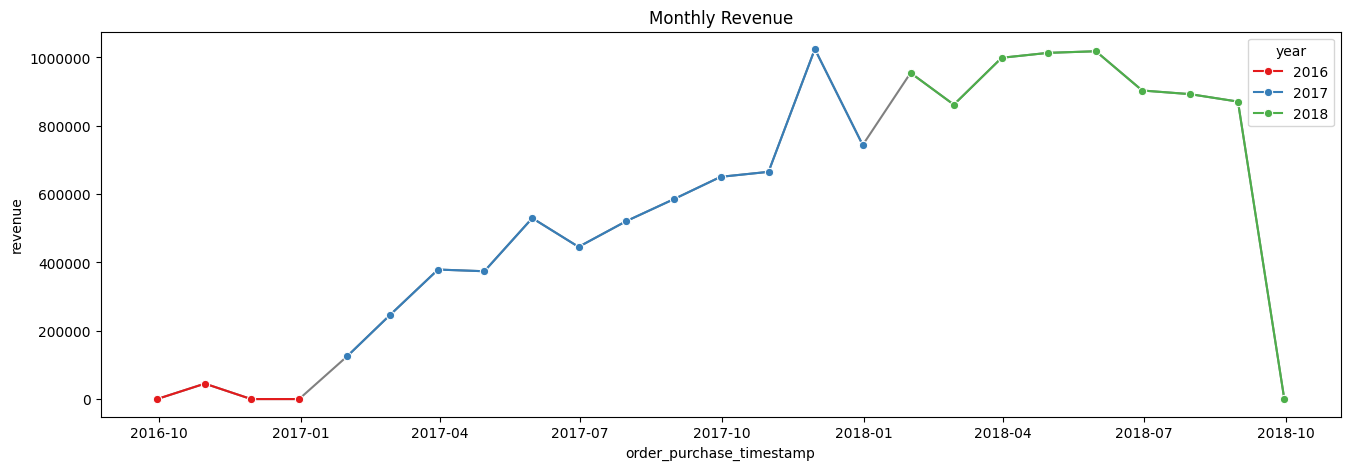

In [128]:
plt.figure(figsize=(16, 5))
plt.plot(monthly_revenue_yoy['order_purchase_timestamp'], monthly_revenue_yoy['revenue'], color='gray', alpha=1, zorder=1)
sns.lineplot(data=monthly_revenue_yoy, x='order_purchase_timestamp', y='revenue', hue='year', palette='Set1', marker='o')
plt.ticklabel_format(style='plain', axis='y')
plt.title("Monthly Revenue")
plt.show()

In [90]:
monthly_orders_yoy = all_df.resample(rule='ME', on='order_purchase_timestamp').agg({
    "order_id": "nunique"
}).reset_index()
monthly_orders_yoy.rename(columns={
    "order_id": "counts"
}, inplace=True)
monthly_orders_yoy['year'] = monthly_orders_yoy['order_purchase_timestamp'].dt.year
monthly_orders_yoy.sort_values(by='year', ascending=True)

,order_purchase_timestamp,counts,year
0,2016-09-30,1,2016
1,2016-10-31,283,2016
2,2016-11-30,0,2016
3,2016-12-31,1,2016
4,2017-01-31,763,2017
5,2017-02-28,1645,2017
6,2017-03-31,2548,2017
7,2017-04-30,2298,2017
8,2017-05-31,3522,2017
9,2017-06-30,3129,2017


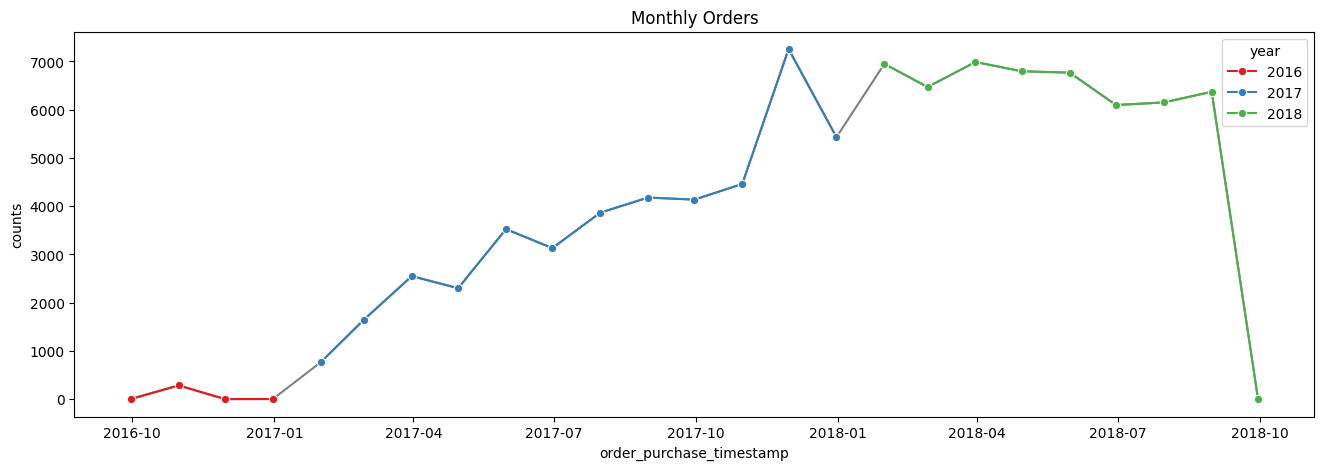

In [127]:
plt.figure(figsize=(16, 5))
plt.plot(monthly_orders_yoy['order_purchase_timestamp'], monthly_orders_yoy['counts'], color='gray', alpha=1, zorder=1)
sns.lineplot(data=monthly_orders_yoy, x='order_purchase_timestamp', y='counts', hue='year', palette='Set1', marker='o')
plt.title("Monthly Orders")
plt.show()

### Pertanyaan 2: Berapa lama rata-rata waktu pengiriman dalam satu tahun terakhir?

In [92]:
yoy = all_df[(all_df["order_purchase_timestamp"] >= '2017-09') & 
                (all_df["order_purchase_timestamp"] <= '2018-09')]
delivery_time = yoy['delivery_time'].describe()

In [93]:
delivery_time

count    86947.000000
mean         9.239571
std          8.522599
min          0.000000
25%          4.000000
50%          7.000000
75%         12.000000
max        205.000000
Name: delivery_time, dtype: float64

### Pertanyaan 3: Apa 4 payment method yang paling sering digunakan customer dalam satu tahun terakhir?

In [94]:
yoy = all_df[(all_df["order_purchase_timestamp"] >= '2017-09') & 
                (all_df["order_purchase_timestamp"] <= '2018-09')]
payment_method_yoy = yoy.groupby(by='payment_type').order_id.nunique().reset_index()

payment_method_yoy.columns = ['payment_type', 'order_count']
payment_method_yoy

,payment_type,order_count
0,boleto,14349
1,credit_card,57133
2,debit_card,1292
3,voucher,2636


C:\Users\pasca\AppData\Local\Temp\ipykernel_25936\2089495040.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\pasca\AppData\Local\Temp\ipykernel_25936\2089495040.py:3: UserWarning: The palette list has more values (12) than needed (4), which may not be intended.
  sns.barplot(


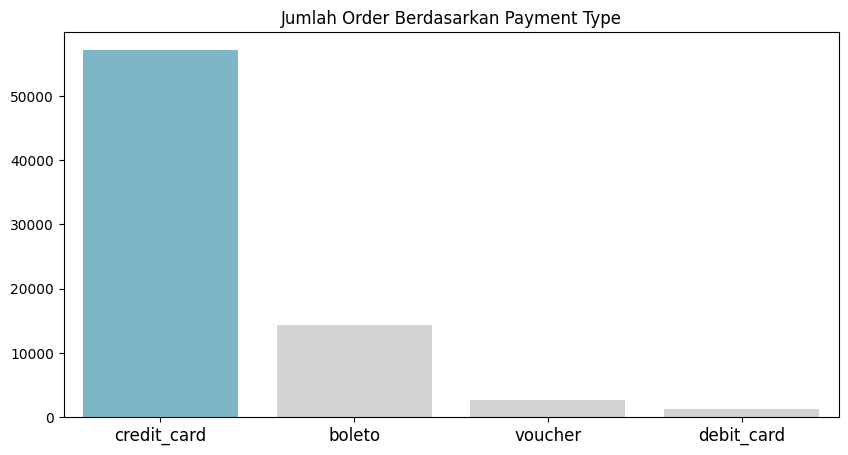

In [95]:
plt.figure(figsize=(10, 5))
colors_ = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
sns.barplot(
    y="order_count",
    x="payment_type", 
    data=payment_method_yoy.sort_values(by="order_count", ascending=False),
    palette=colors_
)

plt.title('Jumlah Order Berdasarkan Payment Type')
plt.ylabel(None)
plt.xlabel(None)
plt.tick_params(axis='x', labelsize=12)
plt.show()

### Pertanyaan 4: Kategori produk apa yang menghasilkan orders terbanyak?

In [96]:
yoy = all_df[(all_df["order_purchase_timestamp"] >= '2017-09') & 
                (all_df["order_purchase_timestamp"] <= '2018-09')]
yoy = yoy.drop_duplicates(subset=['order_id'])
category_sales_yoy = yoy.groupby(by='product_category_name').order_id.nunique().reset_index()
category_sales_yoy.rename(columns={
    'product_category_name' : 'category',
    'order_id' : 'orders',
}, inplace=True)
category_sales_yoy.sort_values(by='orders', ascending=False)

,category,orders
7,bed_bath_table,6950
43,health_beauty,6945
67,sports_leisure,5797
15,computers_accessories,5147
72,watches_gifts,4737
...,...,...
11,cds_dvds_musicals,6
29,fashion_childrens_clothes,5
52,la_cuisine,4
59,pc_gamer,2


C:\Users\pasca\AppData\Local\Temp\ipykernel_25936\73718202.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\pasca\AppData\Local\Temp\ipykernel_25936\73718202.py:2: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  sns.barplot(


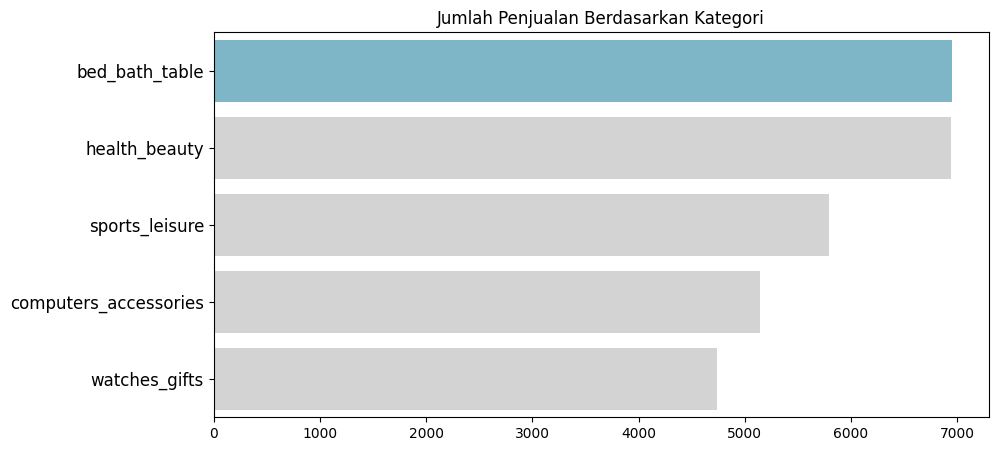

In [97]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x='orders',
    y='category',
    data=category_sales_yoy.sort_values(by='orders', ascending=False).head(),
    palette=colors_)
plt.title('Jumlah Penjualan Berdasarkan Kategori')
plt.ylabel(None)
plt.xlabel(None)
plt.tick_params(axis='y', labelsize=12)
plt.show()


### Pertanyaan 5: Kategori produk apa yang menghasilkan revenue tertinggi?

In [98]:
yoy = all_df[(all_df["order_purchase_timestamp"] >= '2017-09') & 
                (all_df["order_purchase_timestamp"] <= '2018-09')]
category_revenue_yoy = yoy.groupby(by='product_category_name').agg({
    'price':'sum'
}).reset_index()
category_revenue_yoy.rename(columns={
    'product_category_name' : 'category',
    'price': 'revenue'
}, inplace=True)
category_revenue_yoy.sort_values(by='revenue', ascending=False)

,category,revenue
43,health_beauty,1025883.94
72,watches_gifts,1020913.39
7,bed_bath_table,810787.07
67,sports_leisure,771206.91
15,computers_accessories,708895.32
...,...,...
59,pc_gamer,786.99
11,cds_dvds_musicals,370.00
29,fashion_childrens_clothes,299.95
46,home_comfort_2,228.49


C:\Users\pasca\AppData\Local\Temp\ipykernel_25936\2737919093.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\pasca\AppData\Local\Temp\ipykernel_25936\2737919093.py:2: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  sns.barplot(


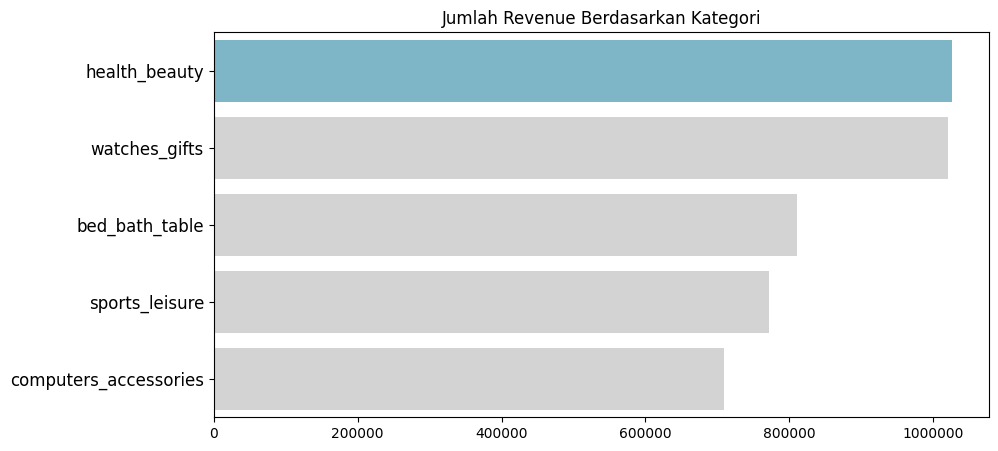

In [99]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x='revenue',
    y='category',
    data=category_revenue_yoy.sort_values(by='revenue', ascending=False).head(),
    palette=colors_)
plt.title('Jumlah Revenue Berdasarkan Kategori')
plt.ylabel(None)
plt.xlabel(None)
plt.tick_params(axis='y', labelsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.show()

### Pertanyaan 6: Bagaimana Performa Review Customer?

In [100]:
yoy = all_df[(all_df["order_purchase_timestamp"] >= '2017-09') & 
                (all_df["order_purchase_timestamp"] <= '2018-09')]
yoy = yoy.drop_duplicates(subset=['order_id'])
review_summary_yoy = yoy.groupby('review_status').order_id.nunique().reset_index()
review_summary_yoy.rename(columns={
    'order_id':'count'
}, inplace=True)
review_summary_yoy

,review_status,count
0,complete review,9628
1,incomplete review,22028
2,no review,42191


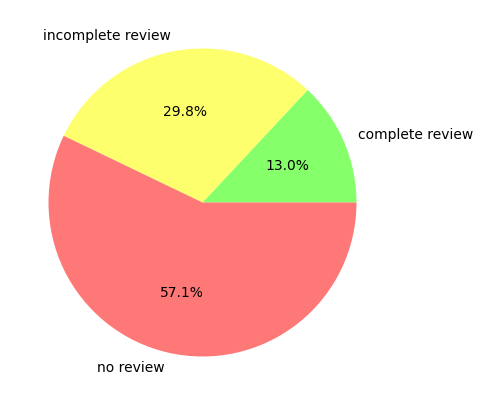

In [101]:
plt.figure(figsize=(10, 5))
pie_colors = ["#85FF6A", "#FDFF6C", "#FF7878" ]

plt.pie(
    review_summary_yoy['count'],
    labels=review_summary_yoy['review_status'],
    autopct='%1.1f%%',
    colors=pie_colors
)

plt.show()

### Pertanyaan 7: Dimanakah kota & state yang mempunyai orders terbanyak dalam satu tahun terakhir?

In [102]:
yoy =  all_df[(all_df["order_purchase_timestamp"] >= '2017-09') & 
                (all_df["order_purchase_timestamp"] <= '2018-09')]
city_orders_yoy = yoy.groupby(by='customer_city').order_id.nunique().reset_index()
city_orders_yoy.rename(columns={
    "order_id":"counts"
}, inplace=True)

city_orders_yoy.sort_values(by='counts', ascending=False)

,customer_city,counts
3225,sao paulo,11875
2829,rio de janeiro,4984
414,belo horizonte,2112
510,brasilia,1661
1040,curitiba,1154
...,...,...
3697,xexeu,1
1130,elisiario,1
1131,elisio medrado,1
1133,embauba,1


In [103]:
state_orders_yoy = yoy.groupby(by='customer_state').order_id.nunique().reset_index()
state_orders_yoy.rename(columns={
    "order_id":"counts"
}, inplace=True)

state_orders_yoy.sort_values(by='counts', ascending=False)

,customer_state,counts
25,SP,31660
18,RJ,9361
10,MG,8626
22,RS,3913
17,PR,3682
23,SC,2647
4,BA,2484
6,DF,1661
7,ES,1499
8,GO,1477


C:\Users\pasca\AppData\Local\Temp\ipykernel_25936\3968817628.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\pasca\AppData\Local\Temp\ipykernel_25936\3968817628.py:3: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  sns.barplot(
C:\Users\pasca\AppData\Local\Temp\ipykernel_25936\3968817628.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\pasca\AppData\Local\Temp\ipykernel_25936\3968817628.py:16: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  sns.barplot(


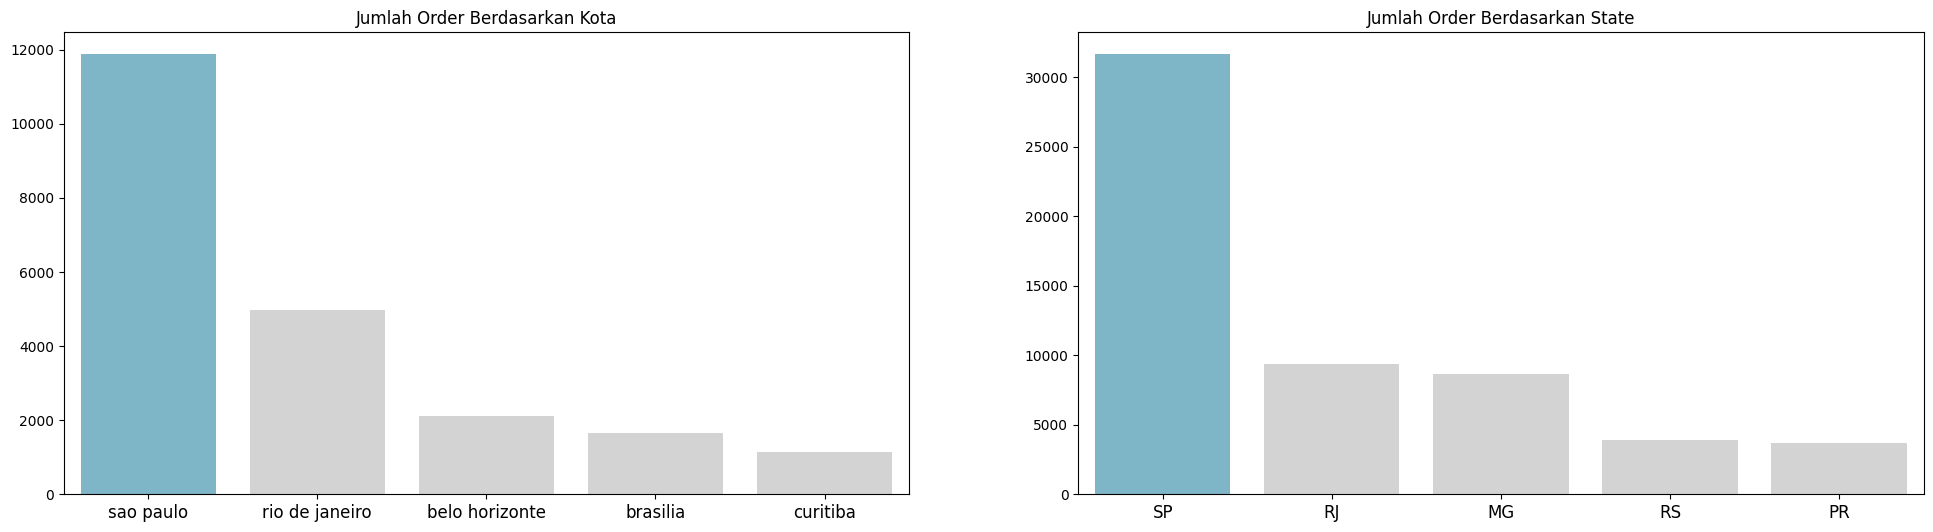

In [104]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

sns.barplot(
    y='counts',
    x='customer_city',
    data=city_orders_yoy.sort_values(by='counts', ascending=False).head(5),
    palette=colors_,
    ax=ax[0]
)

ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Jumlah Order Berdasarkan Kota")
ax[0].tick_params(axis='x', labelsize=12)

sns.barplot(
    y='counts',
    x='customer_state',
    data=state_orders_yoy.sort_values(by='counts', ascending=False).head(5),
    palette=colors_,
    ax=ax[1]
)

ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("Jumlah Order Berdasarkan State")
ax[1].tick_params(axis='x', labelsize=12)

In [105]:
state_city = all_df.groupby(by='customer_state')['customer_city'].apply(list).reset_index()
state_city_detail = state_city.explode('customer_city')
state_city_detail = state_city_detail.drop_duplicates()
target_cities = ['sao paulo', 'rio de janeiro', 'belo horizonte', 'brasilia', 'curitiba']
combined_df = state_city_detail[state_city_detail['customer_city'].isin(target_cities)]
combined_df

,customer_state,customer_city
6,DF,brasilia
10,MG,belo horizonte
17,PR,curitiba
18,RJ,rio de janeiro
25,SP,sao paulo


### Pertanyaan 8: Dimanakah kota & state yang menghasilkan revenue tertinggi dalam satu tahun terakhir?

In [106]:
yoy =  all_df[(all_df["order_purchase_timestamp"] >= '2017-09') & 
                (all_df["order_purchase_timestamp"] <= '2018-09')]
city_revenue_yoy = yoy.groupby(by='customer_city').agg({
    'price':'sum'
}).reset_index()
city_revenue_yoy.rename(columns={
    "price":"revenue"
}, inplace=True)
city_revenue_yoy.sort_values(by='revenue', ascending=False)


,customer_city,revenue
3225,sao paulo,1535977.02
2829,rio de janeiro,750428.02
414,belo horizonte,284356.69
510,brasilia,239780.02
1040,curitiba,170207.44
...,...,...
1761,jenipapo de minas,7.48
3298,senador jose porfirio,6.00
3055,santo antonio do rio abaixo,6.00
2766,recreio,5.99


In [107]:
state_revenue_yoy = yoy.groupby(by='customer_state').agg({
    'price':'sum'
}).reset_index()
state_revenue_yoy.rename(columns={
    "price":"revenue"
}, inplace=True)
state_revenue_yoy.sort_values(by='revenue', ascending=False)


,customer_state,revenue
25,SP,4145503.32
18,RJ,1383772.86
10,MG,1252340.97
22,RS,580265.90
17,PR,525672.07
23,SC,392891.04
4,BA,389016.91
6,DF,239780.02
8,GO,225328.15
7,ES,207661.86


C:\Users\pasca\AppData\Local\Temp\ipykernel_25936\1525300251.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\pasca\AppData\Local\Temp\ipykernel_25936\1525300251.py:3: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  sns.barplot(
C:\Users\pasca\AppData\Local\Temp\ipykernel_25936\1525300251.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\pasca\AppData\Local\Temp\ipykernel_25936\1525300251.py:17: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  sns.barplot(


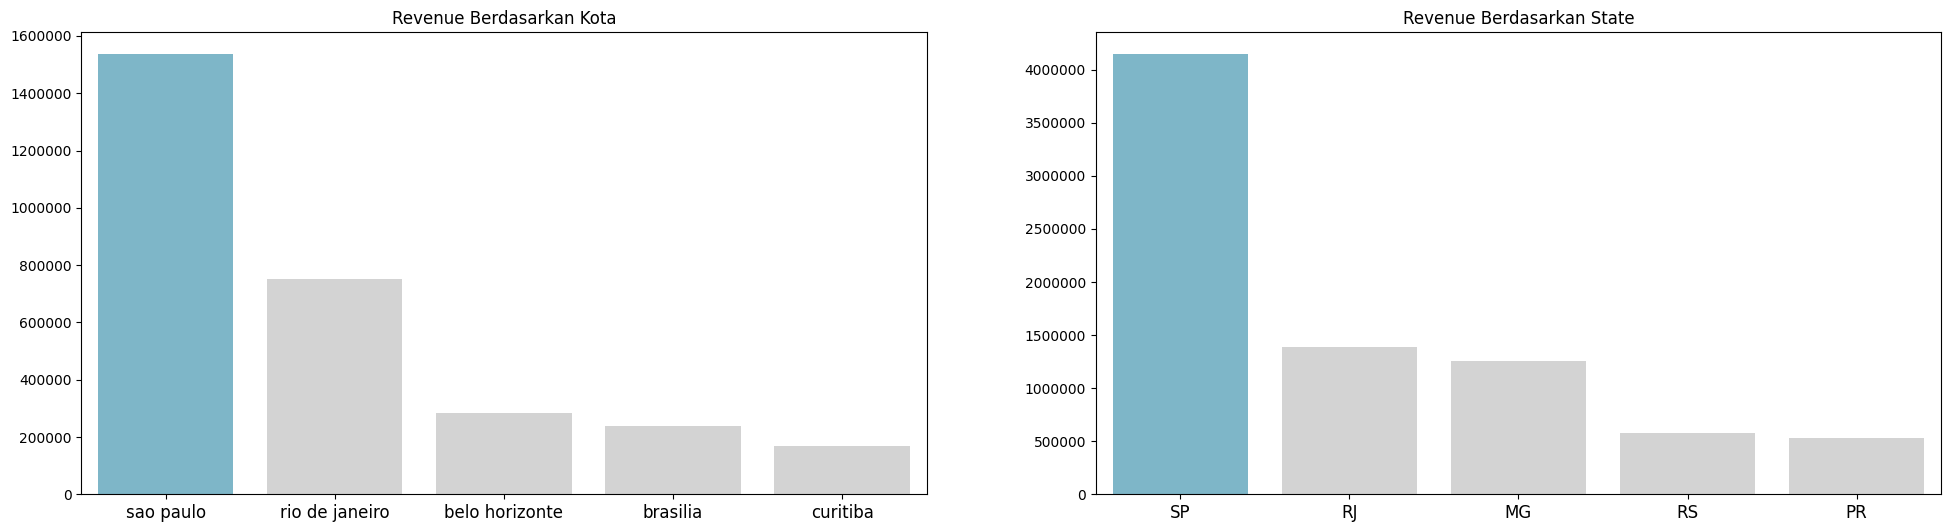

In [108]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

sns.barplot(
    y='revenue',
    x='customer_city',
    data=city_revenue_yoy.sort_values(by='revenue', ascending=False).head(5),
    palette=colors_,
    ax=ax[0]
)

ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Revenue Berdasarkan Kota")
ax[0].tick_params(axis='x', labelsize=12)
ax[0].ticklabel_format(style='plain', axis='y')

sns.barplot(
    y='revenue',
    x='customer_state',
    data=state_revenue_yoy.sort_values(by='revenue', ascending=False).head(5),
    palette=colors_,
    ax=ax[1]
)

ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("Revenue Berdasarkan State")
ax[1].tick_params(axis='x', labelsize=12)
ax[1].ticklabel_format(style='plain', axis='y')

In [109]:
state_city = all_df.groupby(by='customer_state')['customer_city'].apply(list).reset_index()
state_city_detail = state_city.explode('customer_city')
state_city_detail = state_city_detail.drop_duplicates()
target_cities = ['sao paulo', 'rio de janeiro', 'belo horizonte', 'brasilia', 'curitiba']
combined_df = state_city_detail[state_city_detail['customer_city'].isin(target_cities)]
combined_df

,customer_state,customer_city
6,DF,brasilia
10,MG,belo horizonte
17,PR,curitiba
18,RJ,rio de janeiro
25,SP,sao paulo


**Insight:**
- Revenue penjualan bulanan pada tahun 2017 cenderung stagnan diangka 600.000 hingga 1.000.000
- Rata-rata delivery time berada di angka 9.13 hari dengan 25% persentil di 4 hari dan 75% persentil di 12 hari
- Terdapat 4 payment method yang paling sering digunakan oleh customer yaitu credit_card dengan pengguna terbanyak yang diikuti oleh boleto, voucher, dan debit card
- bed_bath table adalah produk yang paling banyak terjual diikuti oleh health & beauty, sports & leisure, computer accessories, dan furniture decor
- Performa review menunjukkan bahwa terdapat 57.2% review yang tidak menyantumkan teks sama sekali pada review, dan terdapat 32.75% review yang hanya memuat satu dari review_title & review_text, dan 10% sisanya memberikan review yang lengkap disertai review_title & review_text
- Sao Paulo, rio de janeiro, dan belo horizonte merupakan kota dengan penjualan tertinggi sejumlah 1439, 6610, dan 2671

## Analisis Lanjutan (Opsional)

### Business Questions
- Kapan terakhir kali pelanggan melakukan transaksi?
- Seberapa sering pelanggan melakukan pembelian dalam satu tahun terakhir?
- Berapa nilai 5 pembelian tertinggi dalam satu tahun terakhir?

**Pertanyaan-pertanyaan tersebut merupakan bagian dari RFM Analysis**

In [110]:
yoy = all_df[(all_df["order_purchase_timestamp"] >= '2017-09') & 
                (all_df["order_purchase_timestamp"] <= '2018-09')]

rfm_df = yoy.groupby(by='customer_id', as_index=False).agg({
    "order_purchase_timestamp": 'max',
    'order_id': 'nunique',
    'price': 'sum'
})

# Mengganti nama kolom
rfm_df.columns = ['customer_id', 'latest_order_timestamp', 'frequency', 'monetary']

# Menghitung Kapan terakhir kali pelanggan melakukan transaksi (Recency)
rfm_df["latest_order_timestamp"] = rfm_df["latest_order_timestamp"].dt.date
recent_date = all_df["order_purchase_timestamp"].dt.date.max()
rfm_df["recency"] = rfm_df["latest_order_timestamp"].apply(lambda x: (recent_date - x).days)
 
rfm_df.drop("latest_order_timestamp", axis=1, inplace=True)
rfm_df.head()

,customer_id,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,1,89.80,293
1,000379cdec625522490c315e70c7a9fb,1,93.00,154
2,000419c5494106c306a97b5635748086,1,34.30,185
3,00046a560d407e99b969756e0b10f282,1,120.90,259
4,00050bf6e01e69d5c0fd612f1bcfb69c,1,69.99,351


### Pertanyaan 9, 10, dan 11

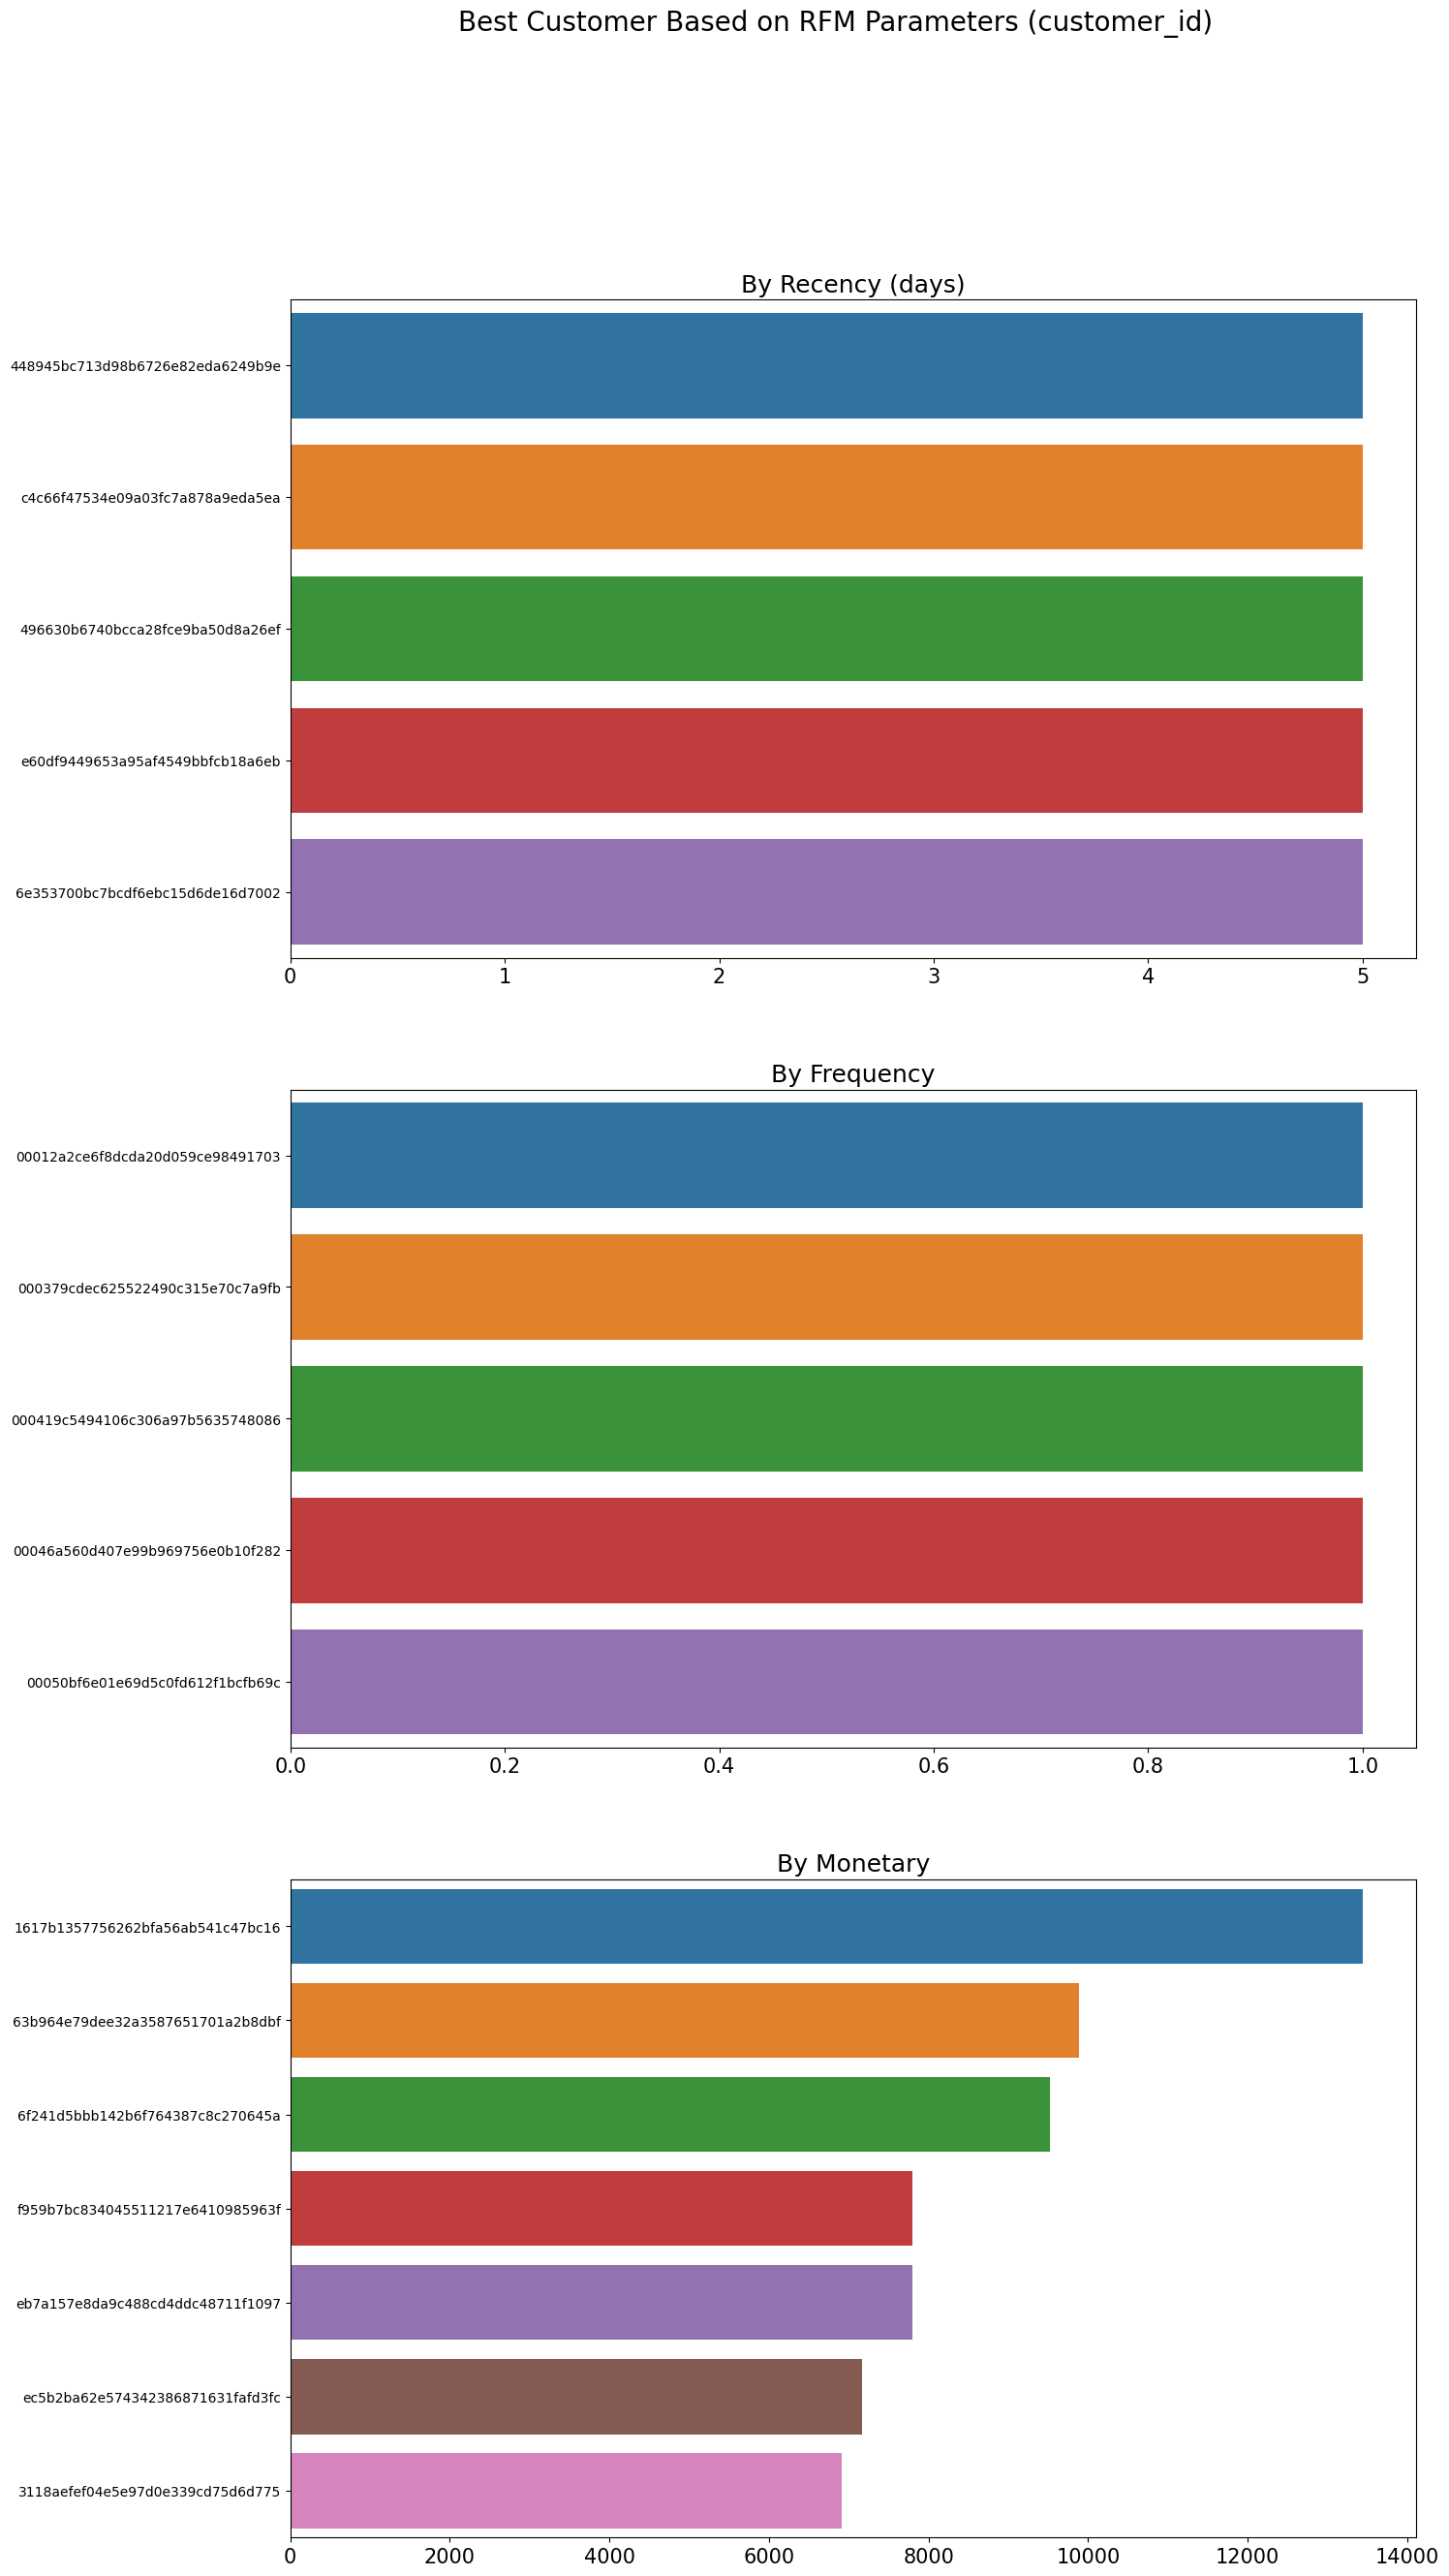

In [111]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(15,30))
 

# Pertanyaan 9: Kapan terakhir kali pelanggan melakukan transaksi?
sns.barplot(y="customer_id", x="recency", data=rfm_df.sort_values(by="recency", ascending=True).head(5), hue='customer_id', ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', labelsize=15)
 
# Pertanyaan 10: Seberapa sering pelanggan melakukan pembelian dalam satu tahun terakhir?
sns.barplot(y="customer_id", x="frequency", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), hue='customer_id', ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=15)
 
# Pertanyaan 11: Berapa nilai 5 pembelian tertinggi dalam satu tahun terakhir?
sns.barplot(y="customer_id", x="monetary", data=rfm_df.sort_values(by="monetary", ascending=False).head(7), hue='customer_id', ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=15)
 
plt.suptitle("Best Customer Based on RFM Parameters (customer_id)", fontsize=20)
plt.show()

In [112]:
rfm_df.sort_values(by="recency", ascending=True).head(5)

,customer_id,frequency,monetary,recency
19811,448945bc713d98b6726e82eda6249b9e,1,457.75,5
57024,c4c66f47534e09a03fc7a878a9eda5ea,1,65.00,5
21210,496630b6740bcca28fce9ba50d8a26ef,1,24.90,5
66494,e60df9449653a95af4549bbfcb18a6eb,1,418.00,5
31775,6e353700bc7bcdf6ebc15d6de16d7002,1,45.90,5


In [113]:
rfm_df.sort_values(by="frequency", ascending=False).head(5)

,customer_id,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,1,89.80,293
1,000379cdec625522490c315e70c7a9fb,1,93.00,154
2,000419c5494106c306a97b5635748086,1,34.30,185
3,00046a560d407e99b969756e0b10f282,1,120.90,259
4,00050bf6e01e69d5c0fd612f1bcfb69c,1,69.99,351


In [124]:
rfm_df.sort_values(by="monetary", ascending=False).head(5)['monetary'].sum()

np.float64(48445.54)

### Mengurutkan Customer berdasarkan RFM Score

In [115]:
rfm_df['r_rank'] = rfm_df['recency'].rank(ascending=False)
rfm_df['f_rank'] = rfm_df['frequency'].rank(ascending=True)
rfm_df['m_rank'] = rfm_df['monetary'].rank(ascending=True)

# Melakukan normalisasi rank
rfm_df['r_rank_norm'] = (rfm_df['r_rank']/rfm_df['r_rank'].max())*100
rfm_df['f_rank_norm'] = (rfm_df['f_rank']/rfm_df['f_rank'].max())*100
rfm_df['m_rank_norm'] = (rfm_df['m_rank']/rfm_df['m_rank'].max())*100
 
rfm_df.drop(columns=['r_rank', 'f_rank', 'm_rank'], inplace=True)

rfm_df.head()

,customer_id,frequency,monetary,recency,r_rank_norm,f_rank_norm,m_rank_norm
0,00012a2ce6f8dcda20d059ce98491703,1,89.80,293,14.426072,100.0,50.101561
1,000379cdec625522490c315e70c7a9fb,1,93.00,154,56.897836,100.0,52.323046
2,000419c5494106c306a97b5635748086,1,34.30,185,47.511579,100.0,16.110336
3,00046a560d407e99b969756e0b10f282,1,120.90,259,26.562796,100.0,65.268731
4,00050bf6e01e69d5c0fd612f1bcfb69c,1,69.99,351,3.118144,100.0,41.368641


In [116]:
# Membuat RFM Scoring dengan 20% Recency, 10% Frequency, dan 70% Monetary
rfm_df['RFM_score'] = 0.2*rfm_df['r_rank_norm']+0.1 * rfm_df['f_rank_norm']+0.7*rfm_df['m_rank_norm']
rfm_df['RFM_score'] *= 0.05
rfm_df = rfm_df.round(2)
rfm_df[['customer_id', 'RFM_score']].head(7)

,customer_id,RFM_score
0,00012a2ce6f8dcda20d059ce98491703,2.40
1,000379cdec625522490c315e70c7a9fb,2.90
2,000419c5494106c306a97b5635748086,1.54
3,00046a560d407e99b969756e0b10f282,3.05
4,00050bf6e01e69d5c0fd612f1bcfb69c,1.98
5,000598caf2ef4117407665ac33275130,4.92
6,0005aefbb696d34b3424dccd0a0e9fd0,3.71


In [117]:
rfm_df.describe()

,frequency,monetary,recency,r_rank_norm,f_rank_norm,m_rank_norm,RFM_score
count,73847.0,73847.000000,73847.000000,73847.000000,73847.0,73847.000000,73847.000000
mean,1.0,143.459666,177.843866,50.003893,100.0,50.000673,2.750049
std,0.0,230.750864,99.468678,28.869515,0.0,28.867315,1.049160
min,1.0,0.850000,5.000000,0.100000,100.0,0.000000,0.500000
25%,1.0,47.900000,94.000000,25.100000,100.0,24.940000,1.870000
50%,1.0,89.700000,177.000000,50.000000,100.0,50.010000,2.750000
75%,1.0,154.000000,265.000000,74.930000,100.0,75.000000,3.630000
max,1.0,13440.000000,367.000000,100.000000,100.0,100.000000,4.990000


In [118]:
'''Membagi customer berdasarkan RFM score yang dimiliki
RFM Score 2.3 <= 0.5 Low Value Customer
RFM Score 2.3 <= 3.3 Medium Value Customer
RFM Score 3.3 <= 4 High Value Customer
RFM Score 4 <    Top Customer
'''
rfm_df["customer_segment"] = np.where(
    rfm_df['RFM_score'] > 4, "Top customer", (np.where(
        rfm_df['RFM_score'] > 3.3, "High value customer",(np.where(
            rfm_df['RFM_score'] > 2.3, "Medium value customer", np.where(
                rfm_df['RFM_score'] > 0.5, 'Low value customer', 'Lost customer'))))))

rfm_df[['customer_id', 'RFM_score', 'customer_segment']].head(20)

,customer_id,RFM_score,customer_segment
0,00012a2ce6f8dcda20d059ce98491703,2.40,Medium value customer
1,000379cdec625522490c315e70c7a9fb,2.90,Medium value customer
2,000419c5494106c306a97b5635748086,1.54,Low value customer
3,00046a560d407e99b969756e0b10f282,3.05,Medium value customer
4,00050bf6e01e69d5c0fd612f1bcfb69c,1.98,Low value customer
5,000598caf2ef4117407665ac33275130,4.92,Top customer
6,0005aefbb696d34b3424dccd0a0e9fd0,3.71,High value customer
7,00066ccbe787a588c52bd5ff404590e3,3.81,High value customer
8,00072d033fe2e59061ae5c3aff1a2be5,2.27,Low value customer
9,000bf8121c3412d3057d32371c5d3395,1.09,Low value customer


In [119]:
# Menambahkan RFM Score dan customer segment ke all_df
all_df = pd.merge(
    left = all_df,
    right = rfm_df[['customer_id','recency', 'monetary', 'frequency', 'RFM_score', 'customer_segment']],
    on='customer_id',
    how='left'
)
all_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,delivery_time,recency,monetary,frequency,RFM_score,customer_segment
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,6.0,336.0,89.97,1.0,2.35,Medium value customer
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,6.0,336.0,89.97,1.0,2.35,Medium value customer
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,6.0,336.0,89.97,1.0,2.35,Medium value customer
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,12.0,41.0,118.70,1.0,3.59,High value customer
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,9.0,26.0,159.90,1.0,4.11,Top customer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115060,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,21.0,209.0,174.90,1.0,3.66,High value customer
115061,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,...,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,24.0,NaN,NaN,NaN,NaN,NaN
115062,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,...,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,13.0,238.0,359.98,1.0,4.08,Top customer
115063,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2,d1c427060a0f73f6b889a5c7c61f2ac4,...,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,13.0,238.0,359.98,1.0,4.08,Top customer


In [129]:
customer_segment_df = rfm_df.groupby('customer_segment', as_index=False).customer_id.nunique()

customer_segment_df.rename(columns={
    'customer_id': 'count'
}, inplace=True)
customer_segment_df

,customer_segment,count
0,High value customer,15136
1,Lost customer,2
2,Low value customer,27594
3,Medium value customer,20825
4,Top customer,10290


### Pertanyaan 12: Bagaimana persebaran jumlah pelanggan apabila dibagi menjadi 5 segmen Top customer, High value customer, Medium value customer, Low value customer, dan Lost Customer?

C:\Users\pasca\AppData\Local\Temp\ipykernel_25936\757048535.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


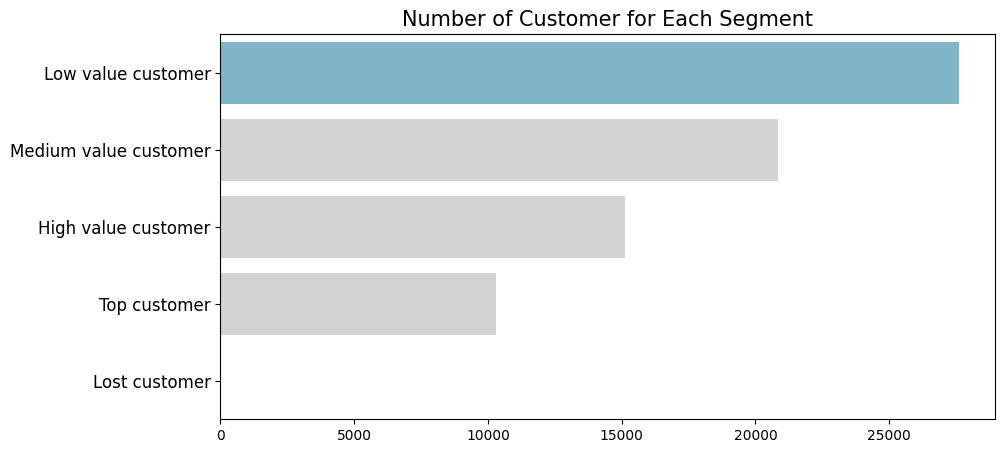

In [121]:
plt.figure(figsize=(10, 5))
colors_ = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x="count", 
    y="customer_segment",
    data=customer_segment_df.sort_values(by="count", ascending=False),
    palette=colors_
)
plt.title("Number of Customer for Each Segment", loc="center", fontsize=15)
plt.ylabel(None)
plt.xlabel(None)
plt.tick_params(axis='y', labelsize=12)
plt.show()
     

In [122]:
all_df.to_csv('dashboard/main_data.csv', index=False)

## Conclusion

**Conclusion Pertanyaan 1**\
Revenue dari penjualan satu tahun terakhir cenderung melandai, hal ini dapat dilihat dari grafik pada tahun 2018 yang cenderung stagnan dibandingkan tahun 2017. Selain itu orders juga menunjukkan hal yang serupa dimana orders melandai bahkan sedikit menurun di tahun 2018 dibandingkan dengan orders pada tahun 2017. Perusahaan perlu mencari "root cause" dari permasalahan ini dan mengoptimasisasikan revenue & memberikan effort extra untuk pemasaran produk agar dapat menumbuhkan revenue & penjualan (orders)

**Conclusion Pertanyaan 2**\
Rata-rata pengiriman berada di angka 9 hari dengan standar deviasi 8.5, hal ini menunjukkan pengiriman mempunyai angka yang sangat variatif, oleh karena itu perusahaan perlu menerapkan strategi optimalisasi layanan pengiriman, hal tersebut dapat dilakukan dengan membuka cabang warehouse, optimalisasi armada yang ada, atau menambah partner pengiriman

**Conclusion Pertanyaan 3**\
Payment method yang paling sering digunakan adalah credit card yang diikuti oleh boleto, voucher, dan debit card. Tingginya angka pengguna credit card merupakan opportunity bagi perusahaan untuk melakukan partnership atau negosiasi fee payment gateway yang akan berpengaruh besar terhadap revenue nantinya

**Conclusion Pertanyaan 4**\
Kategori bed bath table merupakan kategori dengan penjualan (orders) terbanyak diikuti oleh, health and beauty, sports & leisure, computers accessories, dan watches & gifts. Hal ini dapat menjadi ide campaign untuk membundle penjualan bed bath table, health & beauty, dan sports & leisure menjadi healthy living bundle dan computers accessories, dan watches & gifts menjadi bundle gifts

**Conclusion Pertanyaan 5**\
Kategori produk yang memberikan revenue tertinggi adalah health & beauty, diikuti oleh watches & gifts, bed bath table, sports & leisure, dan computer accessories. Walau berada di urutan ke 5 pada jumlah orders watches & gifts berada di urutan kedua pada jumlah revenue yang hampir setara dengan health & beauty, hal ini menunjukkan bahwa watches & gifts memberikan margin yang relatif tinggi dibandingkan kategori top 5 lainnya pada jumlah orders. hal ini dapat menjadi opportunity bagi perusahaan untuk mendorong penjualan watches & gifts yang akan berdampak signifikan terhadap revenue

**Conclusion Pertanyaan 6**\
Mayoritas pelanggan sejumlah 57.1% atau 42.191 hanya memberikan rating tanpa review, selain itu sebagian dari pelanggan sejumlah 29.8% atau 22.028 tidak memberikan review yang lengkap (hanya title, atau hanya teks), dan hanya 13% atau 9628 pelanggan yang memberikan review lengkap. Perusahaan perlu mendorong pelanggan untuk melakukan review agar pelanggan potensial dapat mengetahui kualitas serta detail produk lebih lanjut, hal ini dapat dilakukan dengan memberikan rewards dalam bentuk store credit kepada pelanggan sehingga pelanggan terdorong untuk meninggalkan review

**Conclusion Pertanyaan 7**\
Orders cenderung terkonsentrasi di sao paulo, walau rio de janeiro merupakan kota dengan penjualan tertinggi kedua state rio de janeiro (RJ) memiliki penjualan yang hampir sama dengan penjualan state ketiga yaitu (MG), hal ini menunjukkan adanya konsentrasi pada kota tertentu pada suatu state akan tetapi dalam tingkat state orders tidak menunjukkan perbedaan yang jauh. Hal ini dapat menjadi opportunity bagi perusahaan untuk membentuk warehouse pada state yang kotanya tidak memiliki orders terkonsentrasi (lebih tersebar) sehingga perusahaan dapat menurunkan average delivery time

**Conclusion Pertanyaan 8**\
Sama seperti grafik orders, dapat terlihat bahwa orders terkonsentrasi di Sao Paulo yang diikuti oleh Rio de Janeiro. Hal ini dapat menjadi sinyal untuk perusahaan agar dapat melakukan diversifikasi geografis pelanggan agar tidak terkonsentrasi di Sao Paulo

**Conclusion Pertanyaan 9**\
Pembelian terakhir dilakukan 5 hari yang lalu, perusahaan perlu mendorong penjualan yang lebih rutin agar pembelian dapat terjadi setiap hari

**Conclusion Pertanyaan 10**\
Tidak ada pelanggan yang melakukan pembelian lebih dari satu kali. Perusahaan perlu menambahkan campaign-campaign loyalitas & marketing yang berfokus pada pembelian berulang

**Conclusion Pertanyaan 11**\
Total pembelian pelanggan top 5 adalah 48.455. Walau terdapat beberapa pelanggan yang melakukan pembelian dengan nilai tinggi pembelian tersebut hanya dilakukan satu kali, pembelian yang berulang akan lebih bermanfaat untuk perusahaan dibandingkan spending pelanggan yang tinggi pada situasi saat ini

**Conclusion Pertanyaan 12**\
Pelanggan didominasi oleh low value customer yang diikuti oleh medium value customer, high value customer, top customer, dan yang terakhir lost customer. Jumlah pelanggan yang berurut dari terbanyak yaitu low value ke top value dipengaruhi oleh recency karena pembelian pelanggan yang hanya sekali banyak dari pelanggan lama yang berpindah ke low value customer dan pelanggan top customer yang akan lama kelamaan pindah ke low value customer. Untuk memperbanyak Top customer perusahaan perlu mendorong pembelian berulang yang dapat mengkonversi medium-low customer menjadi top customer melalui recency
